# Plotting Using Pandas

Load data.

In [17]:
# Install datasets Library (if not already installed)
# !pip install -U datasets

# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

## Notes

It is possible to plot things using Pandas. While it's more common to use a dedicated library like Matplotlib for graphing, you can use Pandas to create graphs. This is mostly used as a way to quickly create a graph for an analysis. 

We won't be focusing on it during this course but it's available if you want to.

View more on that [here](https://pandas.pydata.org/docs/user_guide/visualization.html).

## Plotting Series

Below is the data created in `29_Matplotlib_Plotting.ipynb`:

In [18]:
job_counts = df['job_title_short'].value_counts()

job_counts

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64

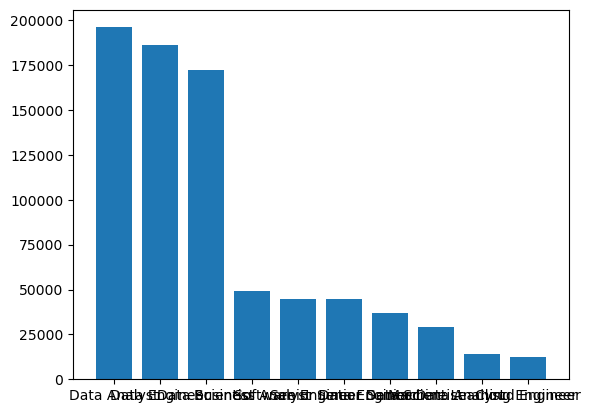

In [19]:
plt.bar(job_counts.index, job_counts) 
plt.show()

Note: We'll fix formatting in a bit...  

Anyway, this is the same chart but using `Pandas` to plot it instead.

<Axes: xlabel='job_title_short'>

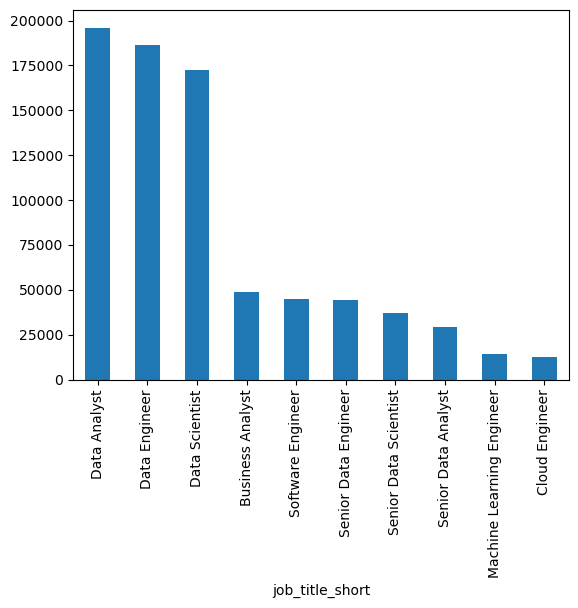

In [20]:
job_counts.plot(kind='bar',x=job_counts.index, y=job_counts)

We can even customize all the labels just like we did in Matplotlib.

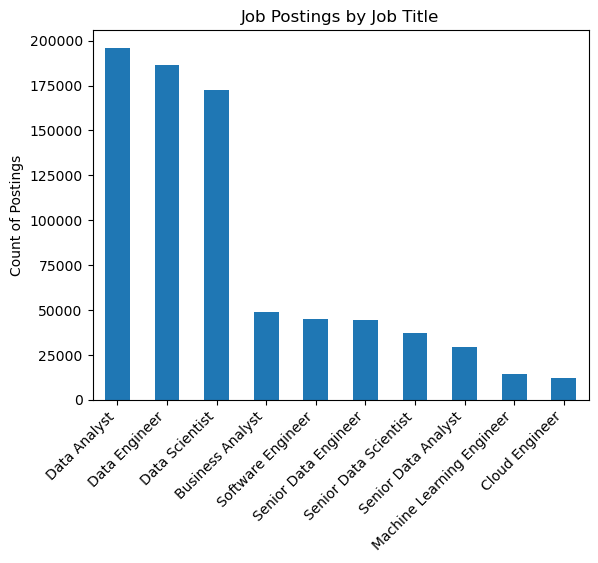

In [21]:
job_counts.plot(kind='bar')
plt.xlabel('')
plt.ylabel('Count of Postings')
plt.title('Job Postings by Job Title')
plt.xticks(rotation=45,ha='right')
plt.show()

## Plotting Dataframes

<Axes: xlabel='job_posted_date'>

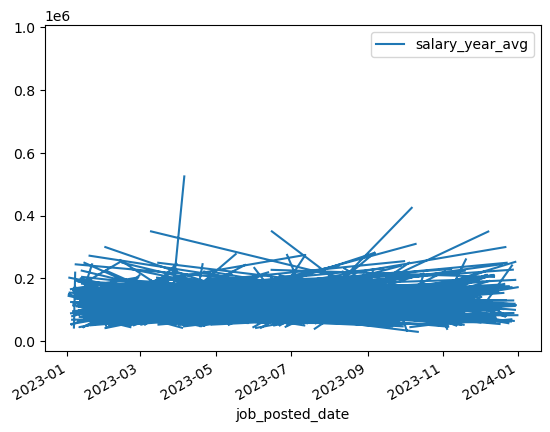

In [22]:
df.plot(x='job_posted_date', y='salary_year_avg', kind='line')

The problem with DataFrames (at least large ones) is the data still may need to be cleaned up.

In [23]:
# sort index by job posted date 
df = df.set_index('job_posted_date')
df.sort_index(inplace=True)
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
job_posted_date,,,,,,,,,,,,,,,,
2023-01-01 00:00:04,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",False,False,United States,None,NaN,NaN,Metasys Technologies,"['sql', 'snowflake', 'visio', 'jira', 'conflue...","{'analyst_tools': ['visio'], 'async': ['jira',..."
2023-01-01 00:00:07,Data Analyst,Data Analyst,"Bloomfield, CT",via CareerBuilder,Full-time,False,"New York, United States",True,False,United States,None,NaN,NaN,Diverse Lynx,"['sql', 'sas', 'sas']","{'analyst_tools': ['sas'], 'programming': ['sq..."
2023-01-01 00:00:22,Data Analyst,Data Analyst,"Washington, DC",via CareerBuilder,Full-time,False,"New York, United States",False,True,United States,None,NaN,NaN,Guidehouse,"['sql', 'python', 'r', 'azure', 'snowflake', '...","{'analyst_tools': ['tableau', 'excel'], 'cloud..."
2023-01-01 00:00:24,Data Analyst,Data Analyst,"Fairfax, VA",via CareerBuilder,Full-time,False,"New York, United States",False,False,United States,None,NaN,NaN,Protask,"['sql', 'jira']","{'async': ['jira'], 'programming': ['sql']}"
2023-01-01 00:00:27,Senior Data Analyst,Senior Data Analyst / Platform Experience,"Worcester, MA",via LinkedIn,Full-time,False,"New York, United States",False,True,United States,None,NaN,NaN,Atria Wealth Solutions,"['sql', 'atlassian', 'jira']","{'async': ['jira'], 'other': ['atlassian'], 'p..."


<Axes: xlabel='job_posted_date'>

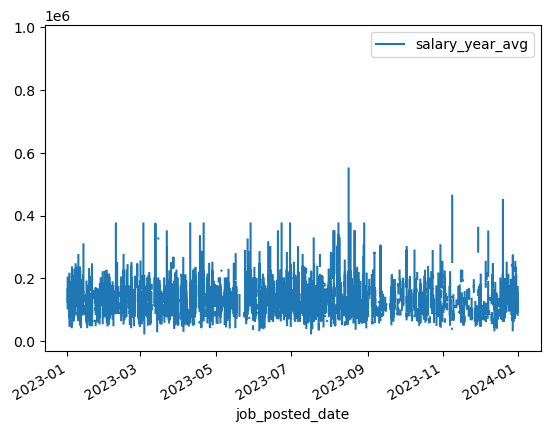

In [24]:
df.plot(kind='line',y='salary_year_avg')